In [ ]:
#Do not change anymore

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from matplotlib.ticker import MultipleLocator, FuncFormatter

In [2]:
#given parameters 
G = 6.7e-39 #GeV^-2
chi = 1.6e35 #GeV^-1
T = lambda t: 7.6e21 #GeV^-1
rho = 2.3e-42  #GeV^4
delta = 0.1
H = 1.5e-42 #GeV 
a = 1.0
deltadot = H*delta /(2*np.sqrt(np.pi))

In [3]:
#reference values (green lines in plots):
kref = 115
thetaref = 70  
mref = 50
tendref = 60

#transition points: 
osc = 1e-33 #at m ~ osc oscillations start
k0 = np.sqrt(12*np.pi*G*rho) #case k ~ H

#variable ranges:
m = np.unique(np.r_[np.logspace(-34.5, -31.5, 100),                #GeV
                    np.logspace(np.log10(3*osc), -31.5, 100)])      #extra points at oscillation
theta = np.linspace(0.0, np.pi, 100) 
k = np.unique(np.r_[np.logspace(np.log10(0.001*H), np.log10(0.01*m[mref]), 100), #GeV #this is k/a not k
                    np.logspace(np.log10(0.9*k0), np.log10(1.1*k0), 30)])        #extra points near k ~ H
tend = np.unique(np.r_[np.logspace(31, 34, 100),                   #GeV^-1
                       np.logspace(np.log10(1.5/osc), 34, 120)])     #extra points at oscillation

In [4]:
#usefull combinations
Theta = lambda t, theta, m: m*t + theta
preX = lambda m: 4*np.pi*G*rho*delta/m**3
preY = lambda k, m: 8*np.pi*G*rho*deltadot/(m**2*(12*np.pi*G*rho-k**2))

#deltaT
def XY(time, f, theta, m):  
    t1, t2, t3, t4 = time+a*chi, time, time+a*chi+T(time), time+T(time)
    return f(2*Theta(t1, theta, m)) - f(2*Theta(t2, theta, m)) - f(2*Theta(t3, theta, m)) - f(2*Theta(t4, theta, m)) 

def deltaT(time, theta, k, m): 
    return preX(m) * XY(time, np.sin, theta, m) + preY(k, m)* XY(time, np.cos, theta, m)

#Residual
def R(tend, theta, k, m):
    innerfct = lambda t: deltaT(t, theta, k, m)/T(t)
    tend = tend % (np.pi/m) #integration over full period = 0 -> neglegtion before integration is less expensive
    return quad(innerfct, 0.0, tend)[0]

def residual(tend, theta, k, m):
    residual_m = np.array([R(tend[tendref], theta[thetaref], k[kref], m_) for m_ in m]) /(4.8e31)
    residual_k = np.array([R(tend[tendref], theta[thetaref], k_, m[mref]) for k_ in k]) /(4.8e31)
    residual_theta = np.array([R(tend[tendref], theta_, k[kref], m[mref]) for theta_ in theta]) /(4.8e31)
    residual_tend = np.array([R(tend_, theta[thetaref], k[kref], m[mref]) for tend_ in tend]) /(4.8e31)
    return residual_m, residual_k, residual_theta, residual_tend

In [5]:
#calculation
res = residual(tend, theta, k, m) # yr

In [6]:
#Plotting
def plot_residual(axes, x, y, label='None', refline='None', reflinelabel='None', 
                  xscale='linear', yscale='linear', xlabel='None', ylabel='None', save='None'):
    axes.plot(x, y, color='black', linestyle='None', marker='d', markeredgecolor='black', markersize=3, label=label)
    if refline!='None': axes.axvline(refline, linestyle=':', color='green', label=reflinelabel) #this m-value is used in other plots
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.legend(fontsize=9, framealpha=0.9)
    axes.tick_params(axis='both', labelsize=8)
    plt.grid(axis='y', color='gainsboro') 
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    if save!='None': plt.savefig(save, dpi=300, bbox_inches="tight")

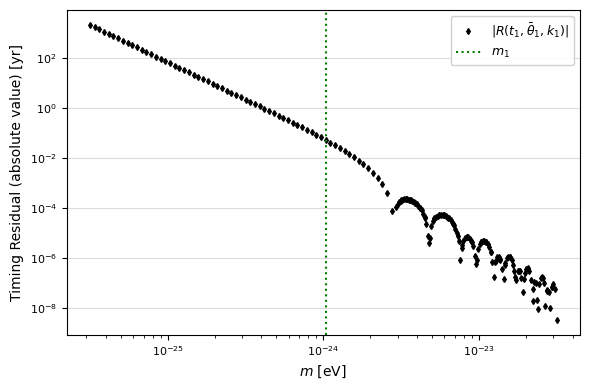

In [7]:
#plot_m_dependence
fig, ax = plt.subplots(figsize=(6, 4)) 
plot_residual(ax, m*1e9, np.abs(res[0]), label=r'$|R (t_1, \bar\theta_1, k_1)|$', refline=m[mref]*1e9, reflinelabel=r'$m_1$', 
              xscale='log', yscale='log', xlabel=r'$m$ [eV]', ylabel=r'Timing Residual (absolute value) [yr]', save='R_m_dependence.png')
plt.show()

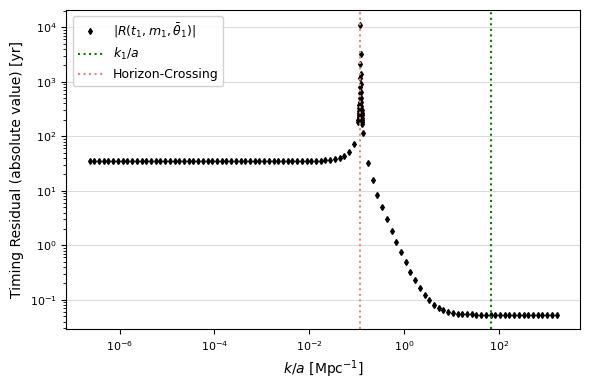

In [8]:
#plot_k_dependence
fig, ax = plt.subplots(figsize=(6, 4)) 
plot_residual(ax, k*1.56e38, np.abs(res[1]), label=r'$|R (t_1, m_1, \bar\theta_1)|$', refline=k[kref]*1.56e38, reflinelabel=r'$k_1/a$', 
              xscale='log', yscale='log', xlabel=r'$k/a$ [Mpc$^{-1}$]', ylabel=r'Timing Residual (absolute value) [yr]', save='R_k_dependence.png')
ax.axvline(k0*1.56e38, linestyle=':', color='lightcoral', label='Horizon-Crossing')
ax.legend(fontsize=9, framealpha=0.9)
plt.show()

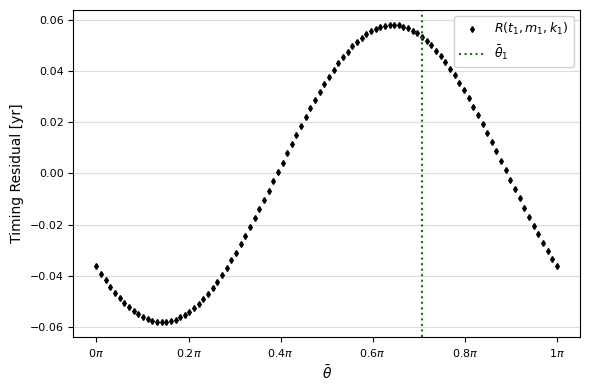

In [9]:
#plot_theta_dependence
fig, ax = plt.subplots(figsize=(6, 4)) 
plot_residual(ax, theta, res[2], label=r'$R (t_1, m_1, k_1)$', refline=theta[thetaref], reflinelabel=r'$\bar\theta_1$', 
              xlabel=r'$\bar\theta$', ylabel=r'Timing Residual [yr]', save='R_theta_dependence.png')
#ax.axvline(theta[thetaref2], linestyle=':', color='blue', label=r'$\bar\theta_2$')
ax.legend(fontsize=9, framealpha=0.9)
ax.yaxis.get_offset_text().set_fontsize(8)
ax.xaxis.set_major_locator(MultipleLocator(np.pi/5))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/np.pi:.2g}$\\pi$"))
plt.show()

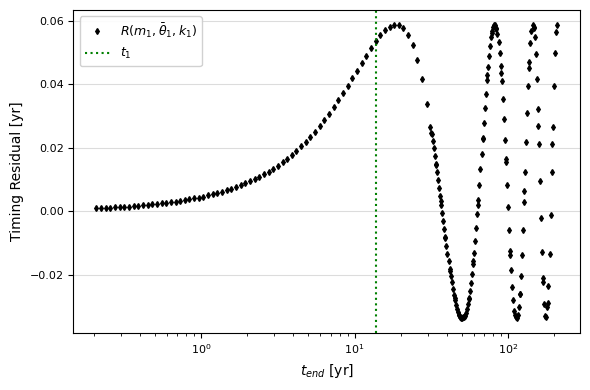

In [10]:
#plot_tend_dependence
fig, ax = plt.subplots(figsize=(6, 4)) 
plot_residual(ax, tend/(4.8e31), res[3], label=r'$R (m_1, \bar\theta_1, k_1)$', refline=tend[tendref]/(4.8e31), reflinelabel=r'$t_1$', 
              xscale = 'log', xlabel=r'$t_{end}$ [yr]', ylabel=r'Timing Residual [yr]', save='R_tend_dependence.png')
plt.show()

In [11]:
#for comparison
#thetaref2 = 80
#res_tend_theta2 = np.array([R(tend_, theta[thetaref2], k[kref], m[mref]) for tend_ in tend]) /(4.8e31) #for comparison
#fig, ax = plt.subplots(figsize=(6, 4)) 
#plot_residual(ax, tend/(4.8e31), res_tend_theta2, label=r'$R (m_1, \bar\theta_2, k_1)$', refline=tend[tendref]/(4.8e31), reflinelabel=r'$t_1$', 
#              xscale = 'log', xlabel=r'$t_{end}$ [yr]', ylabel=r'Timing Residual [yr]', save='R_tend_theta2_dependence.png')
#plt.show()"""